# Lab 5 Report:
## Create Arthur Conan Doyle AI with RNN

### Name:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.distributions import Categorical

# Akhil Samrat
# Lab 5

In [3]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [4]:
#Image('lab5_exercise.png', width = 1000)

## Prepare Data

In [5]:
data_size_to_train = 10000

# Load the Sherlock Holmes data up to data_size_to_train
data = open('/content/drive/MyDrive/Colab Notebooks/Lab5_Template/Lab5_Template/sherlock.txt', 'r').read()[:data_size_to_train]

# Find the set of unique characters within the training data
characters = sorted(list(set(data)))

# total number of characters in the training data and number of unique characters
data_size, vocab_size = len(data), len(characters)

print("Data has {} characters, {} unique".format(data_size, vocab_size))

Data has 10000 characters, 65 unique


In [6]:
# Use Python Dictionary to map the characters to numbers and vice versa

# Create dictionary that converts character into unique number
character_to_num = {ch: i for i, ch in enumerate(characters)}

# Create dictionary that converts unique number into character
num_to_character = {i: ch for i, ch in enumerate(characters)}

In [7]:
# Use the character_to_num dictionary to map each character in the training dataset to a number

data = [character_to_num[ch] for ch in data]

## Define Model

In [8]:
# Define character level rnn model
class CharRNN(torch.nn.Module):

    # Initialize the layers and model settings
    def __init__(self, num_embeddings, embedding_dim, input_size, hidden_size, num_layers, output_size):

        # Call parent pytorch module constructor
        super(CharRNN, self).__init__()

        # Embedding layer converts character indices into dense vectors
        self.embedding = torch.nn.Embedding(num_embeddings, embedding_dim)

        # Recurrent neural network layer
        self.rnn = torch.nn.RNN(input_size=input_size,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                nonlinearity='relu')

        # Fully connected layer that converts hidden states into character predictions
        self.decoder = torch.nn.Linear(hidden_size, output_size)

    # Define forward pass of network
    def forward(self, input_seq, hidden_state):

        # Convert input character numbers into embeddings
        embedding = self.embedding(input_seq)

        # Pass embeddings through RNN layer
        output, hidden_state = self.rnn(embedding, hidden_state)

        # Convert rnn outputs to predicted scores
        output = self.decoder(output)

        # Return the output predictions and detached hidden state
        return output, hidden_state.detach()

## Define Hyperparameters

In [9]:
# Fix random seed
torch.manual_seed(25)

# Define RNN network
rnn = CharRNN(num_embeddings=vocab_size, embedding_dim=100, input_size=100, hidden_size=512, num_layers=3, output_size=vocab_size)

# Define learning rate and epochs
learning_rate = 0.001
epochs = 50

# Size of the input sequence to be used during training and validation
training_sequence_len = 50
validation_sequence_len = 200

# Define loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate)

# add .cuda() for GPU acceleration
rnn

CharRNN(
  (embedding): Embedding(65, 100)
  (rnn): RNN(100, 512, num_layers=3)
  (decoder): Linear(in_features=512, out_features=65, bias=True)
)

## Identify Tracked Values

In [10]:
# Tracking training loss per each input/target sequence fwd/bwd pass
train_loss_list = []

## Train Model

In [11]:
# Convert training data into torch tensor and make it into vertical orientation (N, 1)
# Attach .cuda() if using GPU
data = torch.unsqueeze(torch.tensor(data), dim=1)

# Training Loop --------------------------------------------------------------

for epoch in range(epochs):

    # start training from a random location at the start
    character_loc = np.random.randint(100)

    # Track how many training chunks used in the epoch
    iteration = 0

    # start with no previous hidden state
    hidden_state = None

    # Continue while there's enough text left for one full input/target sequence
    while character_loc + training_sequence_len + 1 < data_size:

        # Input sequence is current block of characters
        input_seq = data[character_loc : character_loc + training_sequence_len]

        # Target seq is same block shifted forward by one character
        target_seq = data[character_loc + 1 : character_loc + training_sequence_len + 1]

        # Run input sequence through RNN
        output, hidden_state = rnn(input_seq, hidden_state)

        # compare predicted characters to target characters
        loss = loss_fn(torch.squeeze(output), torch.squeeze(target_seq))

        # Save loss value for plotting later
        train_loss_list.append(loss.item())

        # clear gradients, find gradients and update model weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Move to next training chunk
        character_loc += training_sequence_len
        iteration += 1

    print("Averaged Training Loss for Epoch {}: {}".format(epoch, np.mean(train_loss_list[-iteration:])))

    # Sample and generate a text sequence after every epoch -------------------

    # Counter for how many validation characters have been generated
    character_loc = 0

    # Reset hidden state before generating text
    hidden_state = None

    # Pick random character to start generated text
    rand_index = np.random.randint(data_size - 1)
    input_seq = data[rand_index : rand_index + 1]

    print("----------------------------------------")
    with torch.no_grad():

        # Generate characters until validation sequence length is reached
        while character_loc < validation_sequence_len:

            # Predict next character
            output, hidden_state = rnn(input_seq, hidden_state)

            # Convert raw model scores to probabilities
            output = torch.nn.functional.softmax(torch.squeeze(output), dim=0)

            # Create probability distribution over possible characters
            character_distribution = torch.distributions.Categorical(output)

            # Randomly sample next character from distribution
            character_num = character_distribution.sample()

            # Print generated character
            print(num_to_character[character_num.item()], end='')

            # Use generated character as next input
            input_seq[0][0] = character_num.item()

            # Increase generated character counter
            character_loc += 1

    print("\n----------------------------------------")

Averaged Training Loss for Epoch 0: 2.722837164546504
----------------------------------------
"Ohe yrese We comesohtenderpe anmin andhery
 IPen to weister.,u isaebe,scu" I daadhanshen
 I Il forg.recudand. I Hemarin eniwthe durithe durdennwenrRerec somend.cottares we somet
" wfremistertortound 
----------------------------------------
Averaged Training Loss for Epoch 1: 2.1601541302911
----------------------------------------
Creinecy,
?
 weringerherehork wartroanelanksingcistone worr-arhed ber
 me
 Inthe in lemeve he catored a deetishylougher ifterdslotkyry, sumotant'athe premaongoronere lovitolvertinn berenc
 anrfe su
 L
----------------------------------------
Averaged Training Loss for Epoch 2: 1.9277047832407543
----------------------------------------
ine the algsablacar roterive to lrige.

 lanchere ol me nokvetwlinather; more." ham I anlu der
 un hr adrerme of the dask the dlov tone and iblatcul?stoudd,""
 undov of dherekond we tory siissed Shere
-------------------------------

## Visualize & Evaluate Model

In [12]:
# Print a validation text sequence that most closely resembles Sherlock Holmes style

In [13]:
# Import seaborn for prettier plot
import seaborn as sns

sns.set(style = 'whitegrid', font_scale = 2.5)

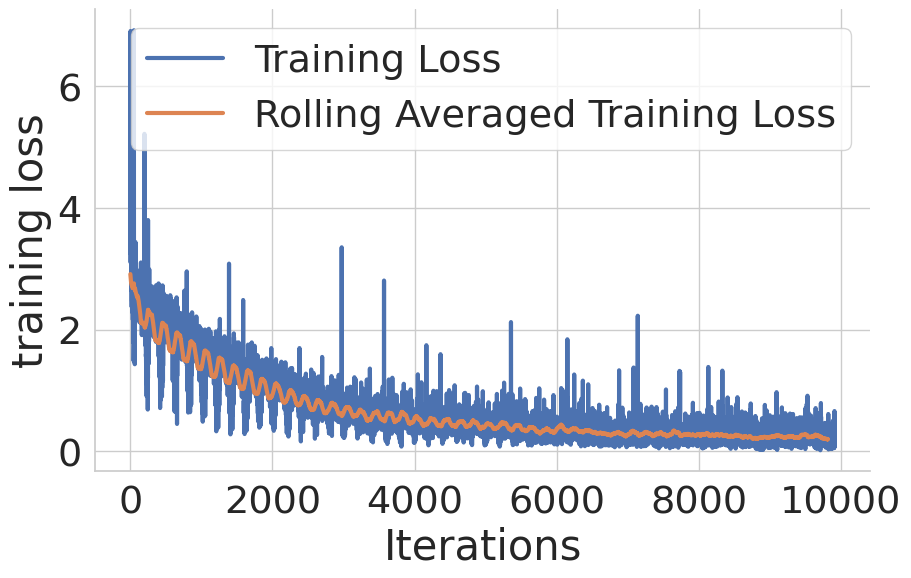

In [14]:
# Plot the training loss and rolling mean training loss with respect to iterations
plt.figure(figsize = (10, 6))

# Plotting
plt.plot(train_loss_list, linewidth = 3, label = 'Training Loss')
plt.plot(np.convolve(train_loss_list, np.ones(100), 'valid') / 100,
         linewidth = 3, label = 'Rolling Averaged Training Loss')
plt.ylabel("training loss")
plt.xlabel("Iterations")
plt.legend()
sns.despine()